In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd
import librosa.display

In [2]:
debussy_file = 'AudioFiles/debussy.wav'
redhot_file = 'AudioFiles/redhot.wav'
duke_file = 'AudioFiles/duke.wav'

In [5]:
debussy,sr = librosa.load(debussy_file)
redhot,_ = librosa.load(redhot_file)
duke,_ = librosa.load(duke_file)

In [7]:
#extracting root mea square energy using librosa
FRAME_LENGTH = 1024
HOP_LENGTH = 512
debussy_rms = librosa.feature.rms(y=debussy,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)
redhot_rms = librosa.feature.rms(y=redhot,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)
duke_rms = librosa.feature.rms(y=duke,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)

In [ ]:
"""
Python provides special symbols to let you restrict how developers use your function signatures:The / Separator (Positional-Only): Parameters before / must only be passed positionally.The * Separator (Keyword-Only): Parameters after * must only be passed using keywords.pythondef configure_system(ip_address, /, timeout, *, secure=True):
    pass

# Usage
configure_system("192.168.1.1", 30, secure=False) #  Valid
configure_system(ip_address="192.168.1.1", timeout=30) # ❌ Invalid (ip
"""

In [8]:
debussy_rms.shape #[[rms1,rms2,rms3....rms1292]]

(1, 1292)

In [9]:
#unpacking
debussy_rms = librosa.feature.rms(y=debussy,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)[0]
redhot_rms = librosa.feature.rms(y=redhot,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)[0]
duke_rms = librosa.feature.rms(y=duke,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)[0]

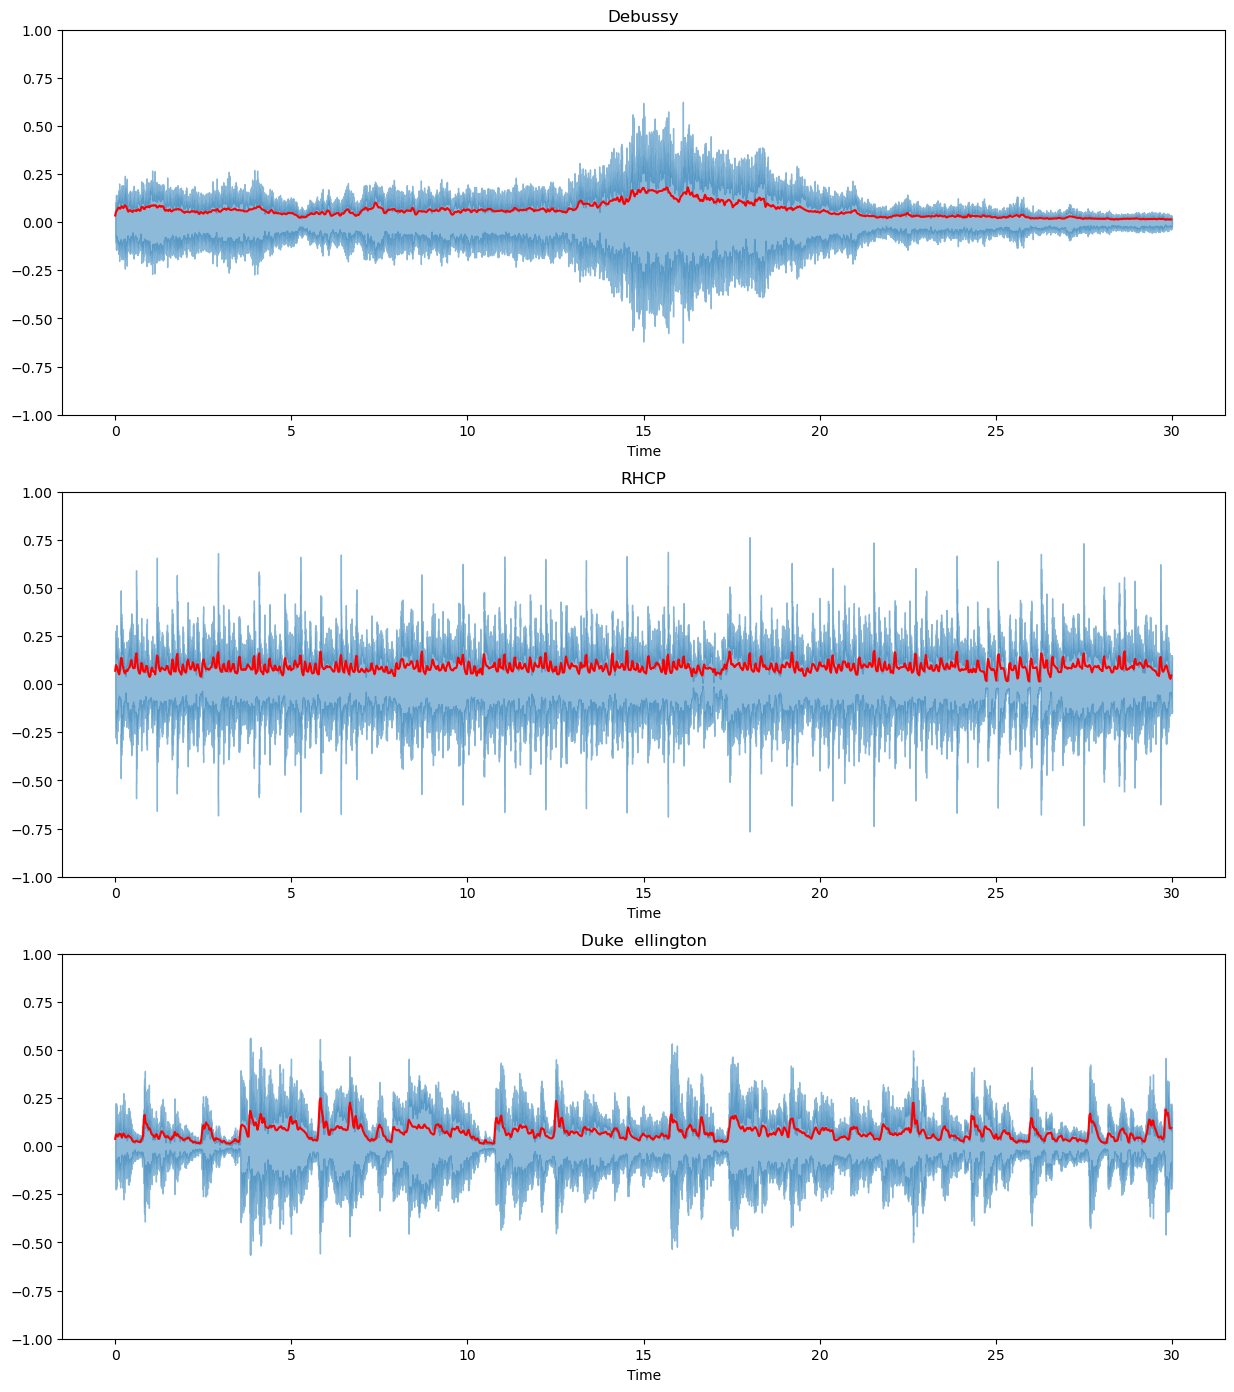

In [11]:
#creating values for the time axis
#plotting the amplitude envelope
#visualizing the waveforms

#frames 
frames = range(debussy_rms.size) # we can choose any of other two as well
t = librosa.frames_to_time(frames,hop_length = HOP_LENGTH)
plt.figure(figsize = (15,17))

plt.subplot(3,1,1)
librosa.display.waveshow(debussy,alpha=0.5)
plt.plot(t,debussy_rms,color="r")
plt.title('Debussy')
plt.ylim((-1,1))

plt.subplot(3,1,2)
librosa.display.waveshow(redhot,alpha=0.5)
plt.plot(t,redhot_rms,color="r")
plt.title('RHCP')
plt.ylim((-1,1))

plt.subplot(3,1,3)
librosa.display.waveshow(duke,alpha=0.5)
plt.plot(t,duke_rms,color="r")
plt.title('Duke  ellington')
plt.ylim((-1,1))

plt.show()

In [12]:
#writing manual function for root mean square
#note : No error — Python slicing never throws an out-of-bounds error
import math

def calc_rms(signal, frame_length, hop_length):
    rms = []
    for i in range(0, len(signal), hop_length):
        frame = signal[i:i+frame_length]
        sum_of_squares = sum(sample**2 for sample in frame)
        mean_of_squares = sum_of_squares / len(frame)
        root_mean_squared = math.sqrt(mean_of_squares)
        rms.append(root_mean_squared)
    return np.array(rms)
        
        

In [17]:
#manual
debussy_rms1 = calc_rms(debussy,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)
redhot_rms1 = calc_rms(redhot,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)
duke_rms1 = calc_rms(duke,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)
debussy_rms - debussy_rms1

array([-0.01806876, -0.00663285, -0.00758305, ..., -0.00103417,
        0.00042985,  0.0018004 ])

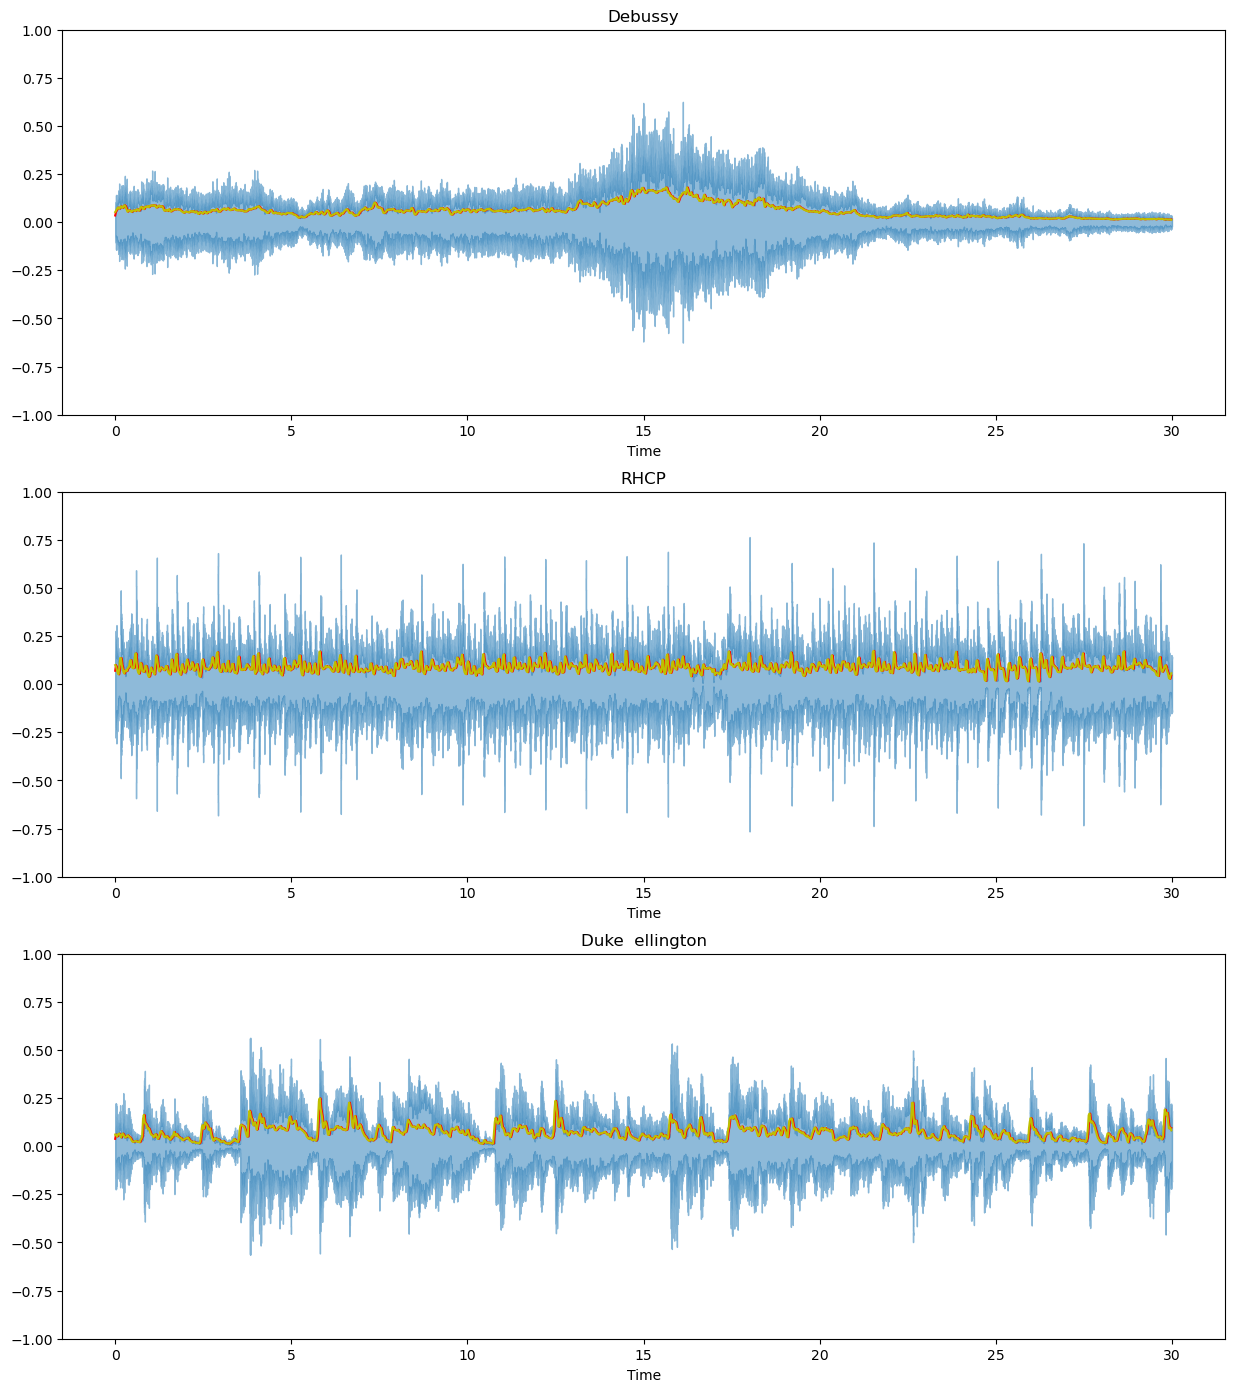

In [19]:
#creating values for the time axis
#plotting the amplitude envelope
#visualizing the waveforms

#frames 
frames = range(debussy_rms.size) # we can choose any of other two as well
t = librosa.frames_to_time(frames,hop_length = HOP_LENGTH)
plt.figure(figsize = (15,17))

plt.subplot(3,1,1)
librosa.display.waveshow(debussy,alpha=0.5)
plt.plot(t,debussy_rms,color="r")
plt.plot(t,debussy_rms1,color="y")
plt.title('Debussy')
plt.ylim((-1,1))

plt.subplot(3,1,2)
librosa.display.waveshow(redhot,alpha=0.5)
plt.plot(t,redhot_rms,color="r")
plt.plot(t,redhot_rms1,color="y")
plt.title('RHCP')
plt.ylim((-1,1))

plt.subplot(3,1,3)
librosa.display.waveshow(duke,alpha=0.5)
plt.plot(t,duke_rms,color="r")
plt.plot(t,duke_rms1,color="y")
plt.title('Duke  ellington')
plt.ylim((-1,1))

plt.show()

In [20]:
Zero Crossing Rate (ZCR) measures how often an audio signal changes sign, meaning how often it crosses the horizontal zero axis.

In simple terms:

It counts how many times the waveform goes from positive to negative or negative to positive in a given frame.

For a discrete audio signal x[n], the zero crossing rate over a frame of length N is:

               N−1
  ZCR=   (1/2N) ∑ ∣sgn(x[n])−sgn(x[n−1])∣
               n=1

where:

sgn(x[n])={
        1,x[n]≥0
       −1,x[n]<0
        }

A simpler implementation-style formula is:

ZCR= number of sign changes/number of samples in the frame

Example:

x=[0.2, 0.1, −0.3, −0.4, 0.5]

Sign sequence:

[+, +, −, −, +]

Zero crossings:

+→−,−→+

So there are 2 zero crossings.

ZCR= 2/5 = 0.4

In audio, high ZCR usually means the signal is noisier, sharper, or has more high-frequency content. Low ZCR usually means smoother, lower-frequency content, like voiced speech or bass-heavy sounds.

SyntaxError: invalid decimal literal (981108667.py, line 9)

In [24]:
debussy_zcr = librosa.feature.zero_crossing_rate(y=debussy,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)[0]
redhot_zcr = librosa.feature.zero_crossing_rate(y=redhot,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)[0]
duke_zcr = librosa.feature.zero_crossing_rate(y=duke,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)[0]

(0.0, 1.0)

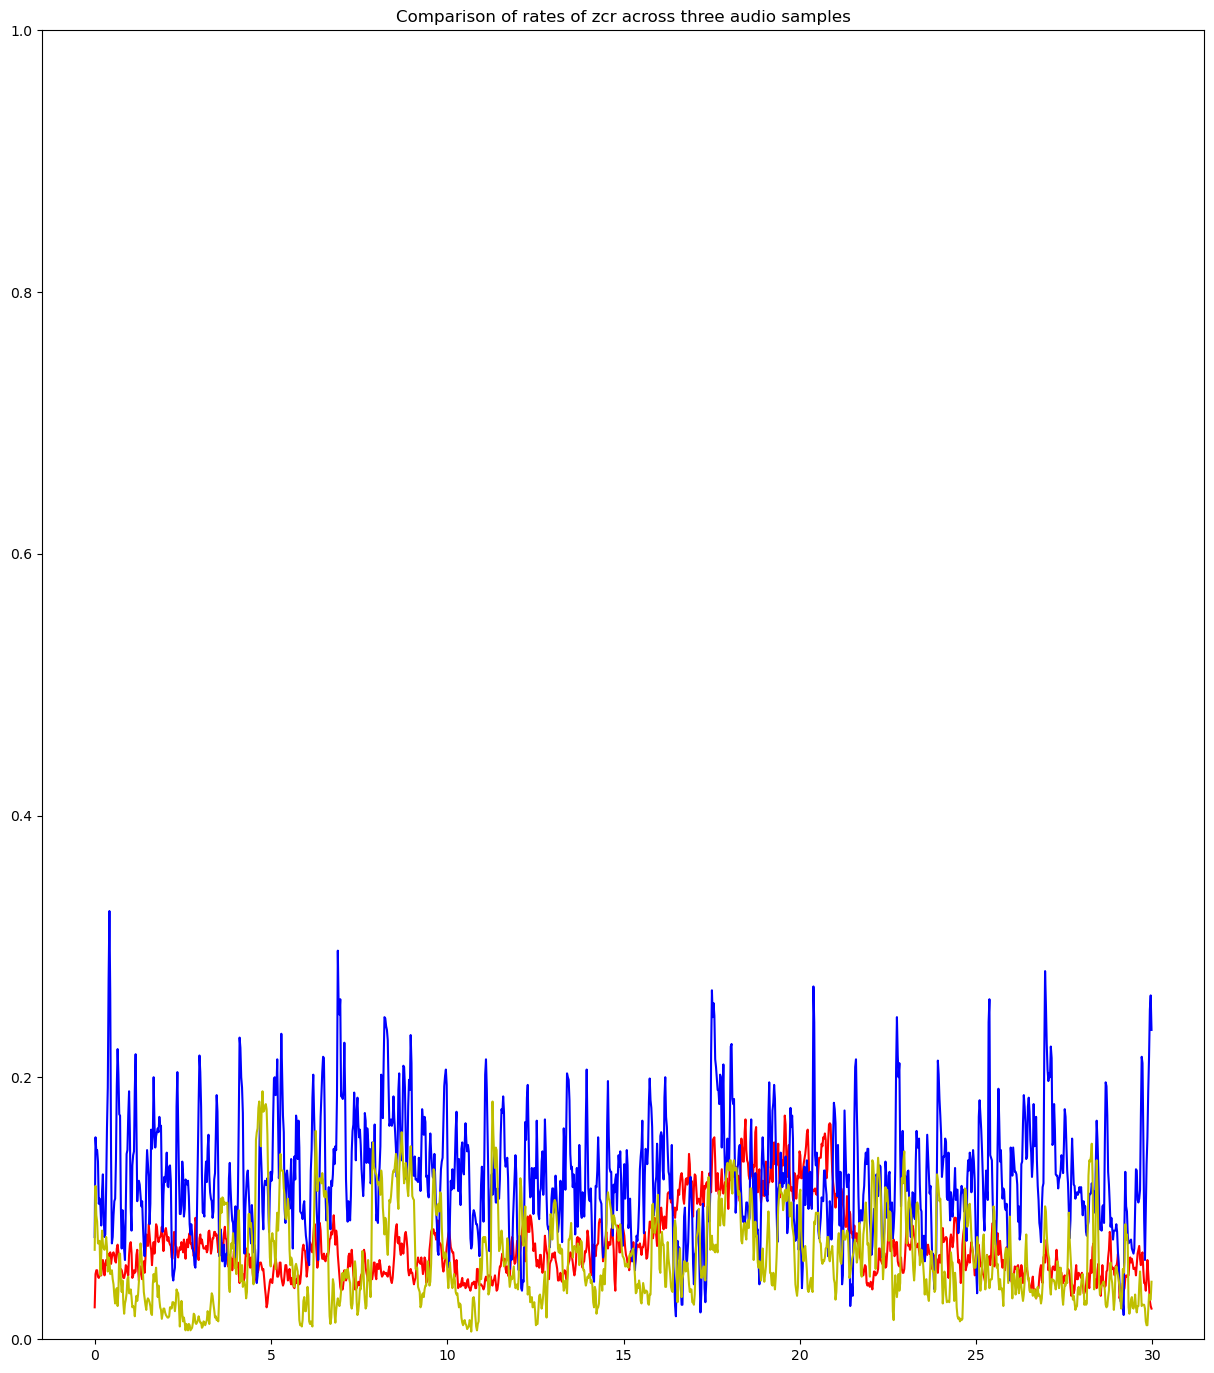

In [31]:
#since this is a rate it should start from 0
plt.figure(figsize = (15,17))
plt.plot(t,debussy_zcr,color="r")
plt.plot(t,redhot_zcr,color="b")
plt.plot(t,duke_zcr,color="y")
plt.title('Comparison of rates of zcr across three audio samples')
plt.ylim((0,1))

In [ ]:
ZCR = number of zero crossings in frame/frame length
hence total no of zero_crossings in frame = frame_length * ZCR


(0.0, 500.0)

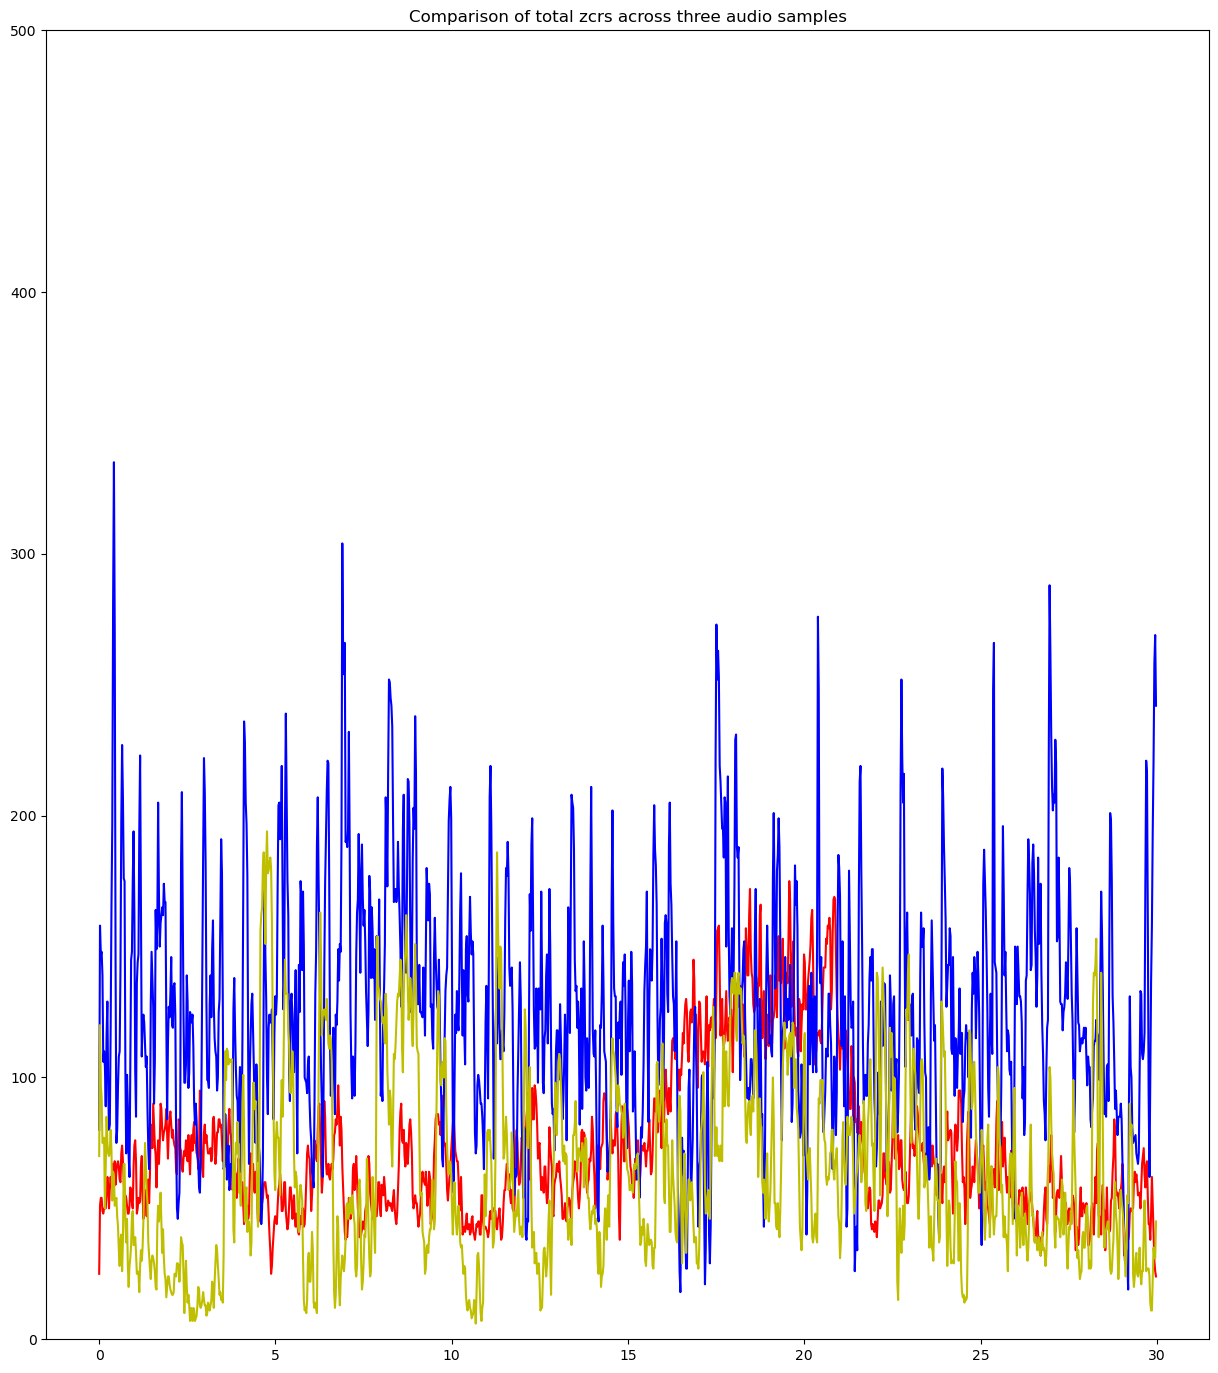

In [30]:
#since this is a rate it should start from 0
plt.figure(figsize = (15,17))
plt.plot(t,debussy_zcr * FRAME_LENGTH,color="r")
plt.plot(t,redhot_zcr * FRAME_LENGTH,color="b")
plt.plot(t,duke_zcr * FRAME_LENGTH,color="y")
plt.title('Comparison of total zcrs across three audio samples')
plt.ylim((0,500))

In [41]:
noise_file = 'AudioFiles/noise.wav'
voice_file = 'AudioFiles/voice.wav'

In [42]:
noise,sr = librosa.load(noise_file,duration=15)
voice,_ = librosa.load(voice_file,duration=15)

In [43]:
voice_zcr = librosa.feature.zero_crossing_rate(y=voice,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)[0]
noise_zcr = librosa.feature.zero_crossing_rate(y=noise,frame_length = FRAME_LENGTH, hop_length = HOP_LENGTH)[0]

In [44]:
frames = range(voice_zcr.size) # we can choose any of other two as well
t = librosa.frames_to_time(frames,hop_length = HOP_LENGTH)

(0.0, 1.0)

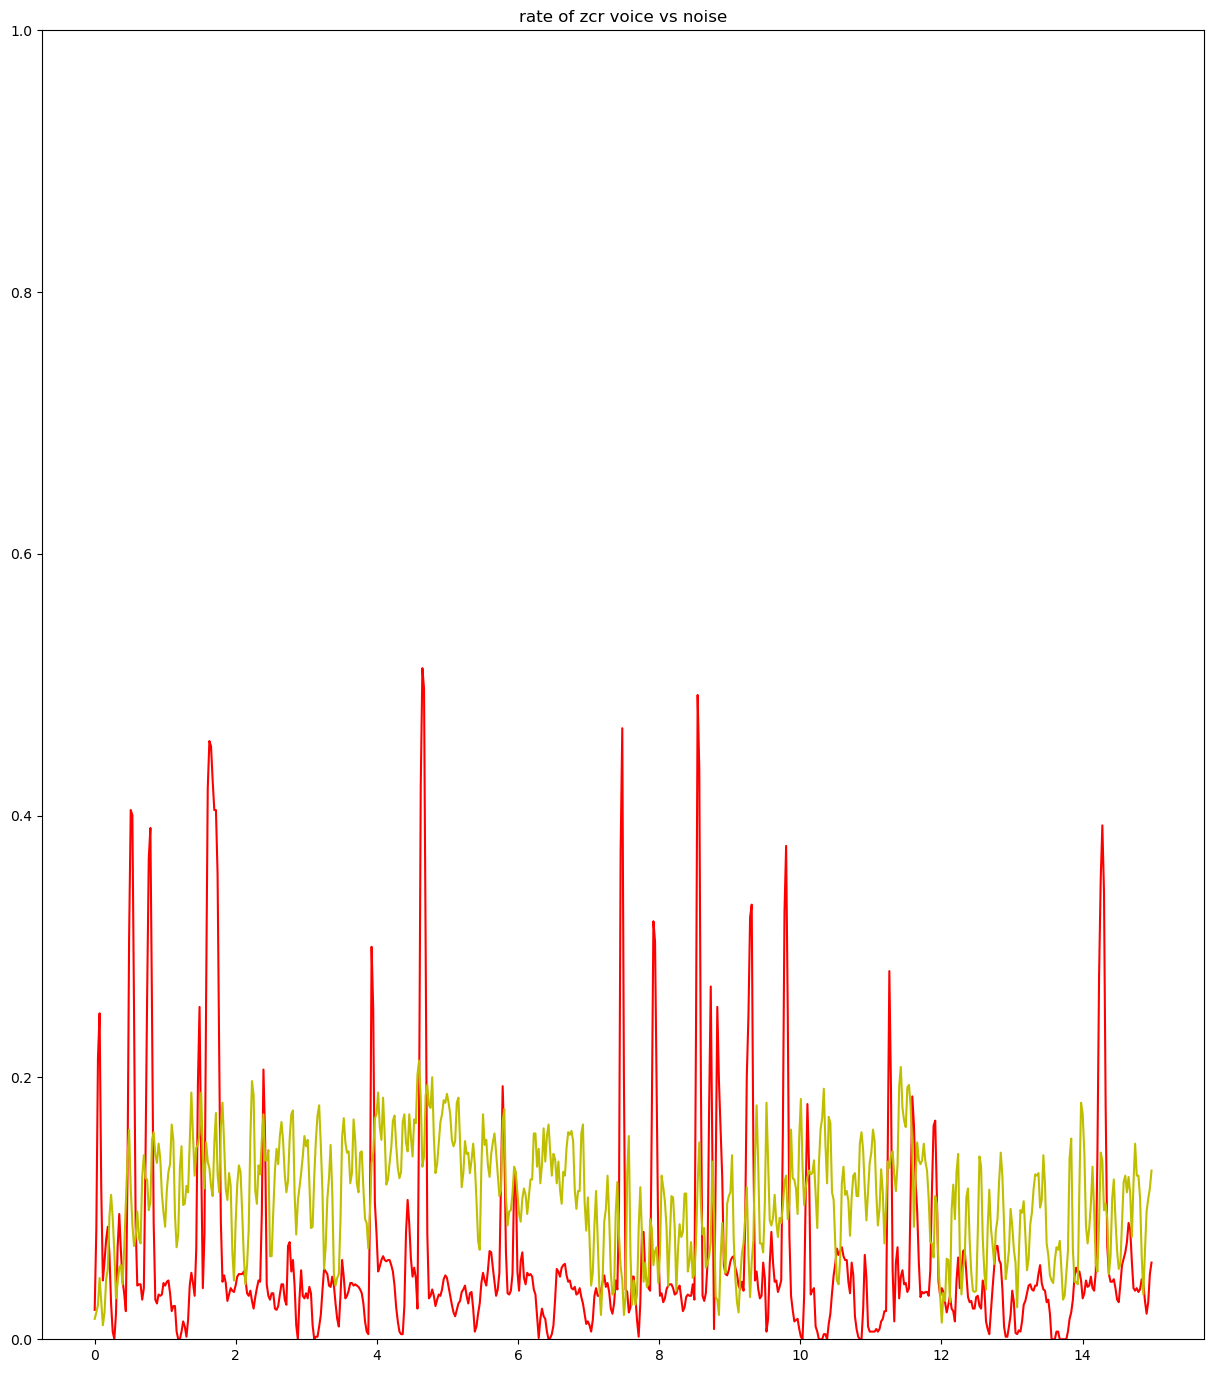

In [45]:
plt.figure(figsize = (15,17))
plt.plot(t,voice_zcr,color="r")
plt.plot(t,noise_zcr,color="y")
plt.title('rate of zcr voice vs noise')
plt.ylim((0,1))